In [23]:
# ============================================================
# PART II - MACHINE LEARNING FOR MORTALITY PREDICTION
# CELL 1 - IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("Libraries Loaded Successfully")
print("=" * 60)

print("Pandas :", pd.__version__)
print("NumPy  :", np.__version__)

Libraries Loaded Successfully
Pandas : 2.3.3
NumPy  : 2.3.5


In [24]:
# ============================================================
# CELL 2 - PROJECT PATHS
# ============================================================

PROJECT_DIR = Path(
    r"C:\Users\abdinasir\Desktop\group2 bit29b"
)

FINAL_DIR = PROJECT_DIR / "data" / "final"

print("Project Directory:")
print(PROJECT_DIR)

print("\nFinal Folder:")
print(FINAL_DIR)

Project Directory:
C:\Users\abdinasir\Desktop\group2 bit29b

Final Folder:
C:\Users\abdinasir\Desktop\group2 bit29b\data\final


In [33]:
# ============================================================
# CELL 3 - VERIFY FINAL DATASETS
# ============================================================

files = sorted(FINAL_DIR.glob("*.csv"))

print(f"Total CSV Files: {len(files)}\n")

for file in files:
    print(file.name)

Total CSV Files: 5

conversion_log.csv
mortality_household.csv
mortality_legacy.csv
SMART_Clean_Dataset.csv
survey_metadata.csv


In [34]:
# ============================================================
# CELL 4 - LOAD DATASETS
# ============================================================

anthro = pd.read_csv(
    FINAL_DIR / "SMART_Clean_Dataset.csv",
    low_memory=False
)

mortality = pd.read_csv(
    FINAL_DIR / "mortality_household.csv",
    low_memory=False
)

metadata = pd.read_csv(
    FINAL_DIR / "survey_metadata.csv"
)

print("=" * 60)
print("Datasets Loaded")
print("=" * 60)

print("Anthropometry :", anthro.shape)
print("Mortality     :", mortality.shape)
print("Metadata      :", metadata.shape)

Datasets Loaded
Anthropometry : (43870, 16)
Mortality     : (26392, 165)
Metadata      : (80, 6)


In [35]:
# ============================================================
# CELL 5 - DATA EXPLORATION
# ============================================================

print("=" * 60)
print("Anthropometry Dataset")
print("=" * 60)

display(anthro.head())

print()

print("=" * 60)
print("Mortality Dataset")
print("=" * 60)

display(mortality.head())

print()

print("=" * 60)
print("Survey Metadata")
print("=" * 60)

display(metadata.head())

Anthropometry Dataset


,SURVDATE,CLUSTER,TEAM,ID,HH,SOURCE_FILE,SEX,MONTHS,WEIGHT,HEIGHT,EDEMA,MUAC,WAZ,HAZ,WHZ,BIRTHDAT
0,2013-11-29,1.0,1.0,1.0,1.0,SOM_2013_admin2_Baydhaba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,1.0,1.0,1.0,1.0,SOM_2013_admin2_BeletWeyne,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-01-04,1.0,1.0,1.0,1.0,SOM_2013_admin2_BeletWeyne_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-12-16,1.0,1.0,1.0,1.0,SOM_2013_admin2_Mogadishu_IDP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-04,1.0,1.0,1.0,1.0,SOM_2014_11_admin1_Bari urban,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Mortality Dataset


,Date,Cluster,Team,HH,P1_sex,P1_age,P1_join,P1_left,P1_born,P1_died,...,P19_location,P20_sex,P20_age,P20_join,P20_left,P20_born,P20_died,P20_cause,P20_location,SOURCE_FILE
0,10/2022,2,2.0,3,m,7.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adado_SMART_survey_2022_final
1,10/2022,2,2.0,2,f,40.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adado_SMART_survey_2022_final
2,10/2022,2,2.0,4,m,7.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adado_SMART_survey_2022_final
3,10/2022,2,2.0,1,f,45.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adado_SMART_survey_2022_final
4,10/2022,2,2.0,5,m,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adado_SMART_survey_2022_final



Survey Metadata


,file_name,survey_type,survey_level,has_mortality,has_anthropometry,destination_folder
0,Adado_SMART_survey_2022_final.as,Individual,Admin2,True,True,admin2/individual
1,Burco Urban_IDPs Complete Anthro_Mortality.as,Individual,Admin2,True,True,admin2/individual
2,Dhobley ENA Anthro & Mortality.as,Individual,Admin2,True,True,admin2/individual
3,Elbarde_Som_Jan_2023.as,Individual,Admin2,True,True,admin2/individual
4,Hudur_Som_Jan_2023.as,Individual,Admin2,True,True,admin2/individual


In [36]:
# ============================================================
# CELL 6 - INSPECT MORTALITY VARIABLES
# ============================================================

# Find all death indicator columns
death_cols = [col for col in mortality.columns if col.endswith("_died")]

print(f"Death indicator columns: {len(death_cols)}\n")

print(death_cols)

print("\n" + "=" * 70)

# Display value counts for each death indicator
for col in death_cols:

    print(f"\n{col}")

    print(mortality[col].value_counts(dropna=False))

Death indicator columns: 20

['P1_died', 'P2_died', 'P3_died', 'P4_died', 'P5_died', 'P6_died', 'P7_died', 'P8_died', 'P9_died', 'P10_died', 'P11_died', 'P12_died', 'P13_died', 'P14_died', 'P15_died', 'P16_died', 'P17_died', 'P18_died', 'P19_died', 'P20_died']


P1_died
P1_died
NaN    26389
y          3
Name: count, dtype: int64

P2_died
P2_died
NaN    26387
y          5
Name: count, dtype: int64

P3_died
P3_died
NaN    26371
y         21
Name: count, dtype: int64

P4_died
P4_died
NaN    26344
y         48
Name: count, dtype: int64

P5_died
P5_died
NaN    26298
y         94
Name: count, dtype: int64

P6_died
P6_died
NaN    26300
y         92
Name: count, dtype: int64

P7_died
P7_died
NaN    26307
y         85
Name: count, dtype: int64

P8_died
P8_died
NaN    26327
y         65
Name: count, dtype: int64

P9_died
P9_died
NaN    26348
y         44
Name: count, dtype: int64

P10_died
P10_died
NaN    26366
y         26
Name: count, dtype: int64

P11_died
P11_died
NaN    26369
y         23
N

In [37]:
# ============================================================
# CELL 7 - CREATE MORTALITY TARGET
# ============================================================

# Replace missing values
mortality[death_cols] = mortality[death_cols].fillna("")

# Create target:
# 1 = at least one household member died
# 0 = no deaths

mortality["TARGET_MORTALITY"] = (
    mortality[death_cols]
    .eq("y")
    .any(axis=1)
    .astype(int)
)

print("=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)

print(mortality["TARGET_MORTALITY"].value_counts())

print()

print("Percentage Distribution:")

print(
    mortality["TARGET_MORTALITY"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

TARGET DISTRIBUTION
TARGET_MORTALITY
0    25890
1      502
Name: count, dtype: int64

Percentage Distribution:
TARGET_MORTALITY
0    98.1
1     1.9
Name: proportion, dtype: float64


In [38]:
# ============================================================
# CELL 8 - VERIFY MERGE KEYS
# ============================================================

print("Anthropometry Columns")
print(anthro.columns.tolist())

print("\n")

print("Mortality Columns")
print(mortality.columns.tolist()[:20])

print("\n")

merge_keys = ["SOURCE_FILE", "CLUSTER", "TEAM", "HH"]

print("Merge Key Check\n")

for key in merge_keys:

    print(key)

    print("Anthropometry :", key in anthro.columns)

    print("Mortality     :", key in mortality.columns)

    print("-" * 40)

Anthropometry Columns
['SURVDATE', 'CLUSTER', 'TEAM', 'ID', 'HH', 'SOURCE_FILE', 'SEX', 'MONTHS', 'WEIGHT', 'HEIGHT', 'EDEMA', 'MUAC', 'WAZ', 'HAZ', 'WHZ', 'BIRTHDAT']


Mortality Columns
['Date', 'Cluster', 'Team', 'HH', 'P1_sex', 'P1_age', 'P1_join', 'P1_left', 'P1_born', 'P1_died', 'P1_cause', 'P1_location', 'P2_sex', 'P2_age', 'P2_join', 'P2_left', 'P2_born', 'P2_died', 'P2_cause', 'P2_location']


Merge Key Check

SOURCE_FILE
Anthropometry : True
Mortality     : True
----------------------------------------
CLUSTER
Anthropometry : True
Mortality     : False
----------------------------------------
TEAM
Anthropometry : True
Mortality     : False
----------------------------------------
HH
Anthropometry : True
Mortality     : True
----------------------------------------


In [9]:
# ============================================================
# CELL 9 - STANDARDIZE MERGE KEYS
# ============================================================

# Rename mortality columns
mortality = mortality.rename(columns={
    "Cluster": "CLUSTER",
    "Team": "TEAM",
    "Date": "SURVDATE"
})

print("Anthropometry Keys")
print(anthro[["SOURCE_FILE", "CLUSTER", "TEAM", "HH"]].head())

print()

print("Mortality Keys")
print(mortality[["SOURCE_FILE", "CLUSTER", "TEAM", "HH"]].head())

Anthropometry Keys
                     SOURCE_FILE  CLUSTER  TEAM   HH
0       SOM_2013_admin2_Baydhaba      1.0   1.0  1.0
1     SOM_2013_admin2_BeletWeyne      1.0   1.0  1.0
2   SOM_2013_admin2_BeletWeyne_2      1.0   1.0  1.0
3  SOM_2013_admin2_Mogadishu_IDP      1.0   1.0  1.0
4  SOM_2014_11_admin1_Bari urban      1.0   1.0  1.0

Mortality Keys
                     SOURCE_FILE CLUSTER  TEAM HH
0  Adado_SMART_survey_2022_final       2   2.0  3
1  Adado_SMART_survey_2022_final       2   2.0  2
2  Adado_SMART_survey_2022_final       2   2.0  4
3  Adado_SMART_survey_2022_final       2   2.0  1
4  Adado_SMART_survey_2022_final       2   2.0  5


In [10]:
# ============================================================
# CELL 10 - CHECK KEY DATA TYPES
# ============================================================

keys = ["SOURCE_FILE", "CLUSTER", "TEAM", "HH"]

print("Anthropometry")

print(anthro[keys].dtypes)

print()

print("Mortality")

print(mortality[keys].dtypes)

Anthropometry
SOURCE_FILE     object
CLUSTER        float64
TEAM           float64
HH             float64
dtype: object

Mortality
SOURCE_FILE     object
CLUSTER         object
TEAM           float64
HH              object
dtype: object


In [11]:
# ============================================================
# CELL 11 - STANDARDIZE DATA TYPES
# ============================================================

# Convert mortality keys to numeric
mortality["CLUSTER"] = pd.to_numeric(mortality["CLUSTER"], errors="coerce")
mortality["HH"] = pd.to_numeric(mortality["HH"], errors="coerce")

# Convert anthropometry keys to numeric
anthro["CLUSTER"] = pd.to_numeric(anthro["CLUSTER"], errors="coerce")
anthro["TEAM"] = pd.to_numeric(anthro["TEAM"], errors="coerce")
anthro["HH"] = pd.to_numeric(anthro["HH"], errors="coerce")

print("Anthropometry")
print(anthro[["CLUSTER", "TEAM", "HH"]].dtypes)

print()

print("Mortality")
print(mortality[["CLUSTER", "TEAM", "HH"]].dtypes)

Anthropometry
CLUSTER    float64
TEAM       float64
HH         float64
dtype: object

Mortality
CLUSTER    float64
TEAM       float64
HH         float64
dtype: object


In [12]:
# ============================================================
# CELL 12 - CHECK MATCH RATE
# ============================================================

# Unique household keys
anthro_keys = anthro[
    ["SOURCE_FILE", "CLUSTER", "TEAM", "HH"]
].drop_duplicates()

mortality_keys = mortality[
    ["SOURCE_FILE", "CLUSTER", "TEAM", "HH"]
].drop_duplicates()

matches = anthro_keys.merge(
    mortality_keys,
    on=["SOURCE_FILE", "CLUSTER", "TEAM", "HH"],
    how="inner"
)

print("=" * 60)
print("Unique Household Keys")
print("=" * 60)

print("Anthropometry :", len(anthro_keys))
print("Mortality     :", len(mortality_keys))
print("Matches       :", len(matches))

print("\nMatch Rate:")
print(f"{len(matches) / len(anthro_keys) * 100:.2f}%")

Unique Household Keys
Anthropometry : 25934
Mortality     : 32866
Matches       : 23987

Match Rate:
92.49%


In [13]:
# ============================================================
# CELL 13 - CREATE FINAL ML DATASET
# ============================================================

# Keep only merge keys and target
mortality_target = mortality[
    ["SOURCE_FILE", "CLUSTER", "TEAM", "HH", "TARGET_MORTALITY"]
].copy()

# Merge datasets
ml_data = anthro.merge(
    mortality_target,
    on=["SOURCE_FILE", "CLUSTER", "TEAM", "HH"],
    how="left"
)

# Fill missing targets with 0
ml_data["TARGET_MORTALITY"] = (
    ml_data["TARGET_MORTALITY"]
    .fillna(0)
    .astype(int)
)

print("=" * 60)
print("Final ML Dataset")
print("=" * 60)

print("Shape:", ml_data.shape)

print("\nTarget Distribution:")
print(ml_data["TARGET_MORTALITY"].value_counts())

print("\nMissing Target Values:")
print(ml_data["TARGET_MORTALITY"].isna().sum())

Final ML Dataset
Shape: (44092, 17)

Target Distribution:
TARGET_MORTALITY
0    43437
1      655
Name: count, dtype: int64

Missing Target Values:
0


In [40]:
# ============================================================
# CELL 14 - SAVE ML DATASET
# ============================================================

ML_DIR = PROJECT_DIR / "data" / "ml"

ML_DIR.mkdir(parents=True, exist_ok=True)

output_file = ML_DIR / "ML_Dataset_Final.csv"

ml_data.to_csv(output_file, index=False)

print("Saved to:")
print(output_file)

Saved to:
C:\Users\abdinasir\Desktop\group2 bit29b\data\ml\ML_Dataset_Final.csv


In [41]:
# ============================================================
# CELL 15 - CHECK DUPLICATES
# ============================================================

print("=" * 60)
print("Checking Duplicate Records")
print("=" * 60)

duplicates = ml_data.duplicated().sum()

print("Duplicate rows:", duplicates)

ml_data = ml_data.drop_duplicates()

print("Shape after removing duplicates:")
print(ml_data.shape)

Checking Duplicate Records
Duplicate rows: 218
Shape after removing duplicates:
(43874, 17)


In [42]:
# ============================================================
# CELL 16 - CHECK MISSING VALUES
# ============================================================

print("=" * 60)
print("Missing Values Analysis")
print("=" * 60)

missing = ml_data.isnull().sum()

display(missing[missing > 0])

print("\nTotal missing values:")
print(missing.sum())

Missing Values Analysis


SURVDATE     3300
CLUSTER      1451
TEAM          556
ID          28440
HH           1123
SEX           135
MONTHS        137
WEIGHT        140
HEIGHT        141
EDEMA         115
MUAC           38
WAZ           193
HAZ           152
WHZ           207
BIRTHDAT    42372
dtype: int64


Total missing values:
78500


In [43]:
# ============================================================
# CELL 17 - HANDLE MISSING VALUES
# ============================================================

print("=" * 60)
print("Handling Missing Values")
print("=" * 60)

# Numeric columns: fill with median
numeric_cols = ml_data.select_dtypes(
    include=["int64", "float64"]
).columns

for col in numeric_cols:
    ml_data[col] = ml_data[col].fillna(
        ml_data[col].median()
    )

# Text columns: fill with mode
object_cols = ml_data.select_dtypes(
    include=["object"]
).columns

for col in object_cols:
    if ml_data[col].isnull().sum() > 0:
        ml_data[col] = ml_data[col].fillna(
            ml_data[col].mode()[0]
        )

print("Remaining missing values:")
print(ml_data.isnull().sum().sum())

Handling Missing Values
Remaining missing values:
0


In [44]:
# ============================================================
# CELL 18 - ENCODE CATEGORICAL VARIABLES
# ============================================================

from sklearn.preprocessing import LabelEncoder

print("=" * 60)
print("Encoding Categorical Variables")
print("=" * 60)

encoded_data = ml_data.copy()

categorical_cols = encoded_data.select_dtypes(
    include=["object"]
).columns

print("Categorical columns:")
print(list(categorical_cols))

for col in categorical_cols:

    encoder = LabelEncoder()

    encoded_data[col] = encoder.fit_transform(
        encoded_data[col].astype(str)
    )

print("\nEncoding completed")

print(encoded_data.dtypes)

Encoding Categorical Variables
Categorical columns:
['SURVDATE', 'SOURCE_FILE', 'SEX', 'EDEMA', 'BIRTHDAT']

Encoding completed
SURVDATE              int64
CLUSTER             float64
TEAM                float64
ID                  float64
HH                  float64
SOURCE_FILE           int64
SEX                   int64
MONTHS              float64
WEIGHT              float64
HEIGHT              float64
EDEMA                 int64
MUAC                float64
WAZ                 float64
HAZ                 float64
WHZ                 float64
BIRTHDAT              int64
TARGET_MORTALITY      int64
dtype: object


In [45]:
# ============================================================
# CELL 19 - PREPARE FEATURES AND TARGET
# ============================================================

print("=" * 60)
print("Preparing Features and Target")
print("=" * 60)

# Use encoded dataset
ml_final = encoded_data.copy()

X = ml_final.drop(
    "TARGET_MORTALITY",
    axis=1
)

y = ml_final["TARGET_MORTALITY"]

print("Features shape:", X.shape)
print("Target shape  :", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Preparing Features and Target
Features shape: (43874, 16)
Target shape  : (43874,)

Target distribution:
TARGET_MORTALITY
0    43219
1      655
Name: count, dtype: int64


In [46]:
# ============================================================
# CELL 20 - TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

print("=" * 60)
print("Train Test Split")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Train Test Split
Training data: (35099, 16)
Testing data : (8775, 16)

Training target:
TARGET_MORTALITY
0    34575
1      524
Name: count, dtype: int64

Testing target:
TARGET_MORTALITY
0    8644
1     131
Name: count, dtype: int64


In [47]:
# ============================================================
# CELL 21 - FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("Feature Scaling")
print("=" * 60)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed")

print("Training shape:", X_train_scaled.shape)
print("Testing shape :", X_test_scaled.shape)

Feature Scaling
Scaling completed
Training shape: (35099, 16)
Testing shape : (8775, 16)


In [48]:
# ============================================================
# CELL 22 - HANDLE CLASS IMBALANCE
# ============================================================

from imblearn.over_sampling import SMOTE

print("=" * 60)
print("Applying SMOTE")
print("=" * 60)

smote = SMOTE(
    random_state=42
)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_balanced.value_counts())

print("\nNew training shape:")
print(X_train_balanced.shape)

Applying SMOTE
Before SMOTE:
TARGET_MORTALITY
0    34575
1      524
Name: count, dtype: int64

After SMOTE:
TARGET_MORTALITY
0    34575
1    34575
Name: count, dtype: int64

New training shape:
(69150, 16)


In [49]:
# ============================================================
# CELL 23 - TRAIN KNN MODEL
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("=" * 60)
print("Training KNN Model")
print("=" * 60)

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_balanced,
    y_train_balanced
)

knn_pred = knn_model.predict(
    X_test_scaled
)

print("Accuracy:")
print(accuracy_score(y_test, knn_pred))

print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, knn_pred))

Training KNN Model
Accuracy:
0.8746438746438746

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.93      8644
           1       0.02      0.15      0.03       131

    accuracy                           0.87      8775
   macro avg       0.50      0.52      0.48      8775
weighted avg       0.97      0.87      0.92      8775


Confusion Matrix:
[[7656  988]
 [ 112   19]]


In [50]:
# ============================================================
# CELL 24 - TRAIN SVM MODEL
# ============================================================

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("=" * 60)
print("Training SVM Model")
print("=" * 60)

svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(
    X_train_balanced,
    y_train_balanced
)

svm_pred = svm_model.predict(
    X_test_scaled
)

print("Accuracy:")
print(accuracy_score(y_test, svm_pred))

print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

Training SVM Model
Accuracy:
0.7201139601139601

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.73      0.84      8644
           1       0.02      0.31      0.03       131

    accuracy                           0.72      8775
   macro avg       0.50      0.52      0.43      8775
weighted avg       0.97      0.72      0.82      8775


Confusion Matrix:
[[6279 2365]
 [  91   40]]


In [51]:
# ============================================================
# CELL 25 - TRAIN DECISION TREE MODEL
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("=" * 60)
print("Training Decision Tree Model")
print("=" * 60)

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

dt_model.fit(
    X_train_balanced,
    y_train_balanced
)

dt_pred = dt_model.predict(
    X_test_scaled
)

print("Accuracy:")
print(accuracy_score(y_test, dt_pred))

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

Training Decision Tree Model
Accuracy:
0.55008547008547

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.55      0.71      8644
           1       0.02      0.54      0.03       131

    accuracy                           0.55      8775
   macro avg       0.50      0.55      0.37      8775
weighted avg       0.97      0.55      0.70      8775


Confusion Matrix:
[[4756 3888]
 [  60   71]]


In [52]:
# ============================================================
# CELL 26 - COMPARE MODEL PERFORMANCE
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=" * 60)
print("Model Performance Comparison")
print("=" * 60)

results = pd.DataFrame({

    "Model": [
        "KNN",
        "SVM",
        "Decision Tree"
    ],

    "Accuracy": [
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, dt_pred)
    ],

    "Precision": [
        precision_score(y_test, knn_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, dt_pred)
    ],

    "Recall": [
        recall_score(y_test, knn_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, dt_pred)
    ],

    "F1 Score": [
        f1_score(y_test, knn_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, dt_pred)
    ]
})

display(results)

print("\nBest Recall Model:")
print(results.loc[results["Recall"].idxmax()])

Model Performance Comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.874644,0.018868,0.145038,0.033392
1,SVM,0.720114,0.016632,0.305344,0.031546
2,Decision Tree,0.550085,0.017934,0.541985,0.034719



Best Recall Model:
Model        Decision Tree
Accuracy          0.550085
Precision         0.017934
Recall            0.541985
F1 Score          0.034719
Name: 2, dtype: object


ROC Curve Comparison
KNN AUC: 0.520
SVM AUC: 0.535
Decision Tree AUC: 0.564


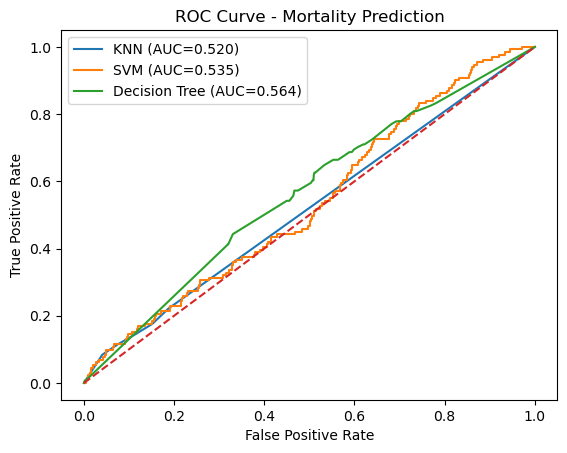

In [53]:
# ============================================================
# CELL 27 - ROC CURVE & AUC COMPARISON
# ============================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

print("=" * 60)
print("ROC Curve Comparison")
print("=" * 60)

# Get probabilities
knn_prob = knn_model.predict_proba(X_test_scaled)[:,1]

svm_prob = svm_model.decision_function(X_test_scaled)

dt_prob = dt_model.predict_proba(X_test_scaled)[:,1]


models = {
    "KNN": knn_prob,
    "SVM": svm_prob,
    "Decision Tree": dt_prob
}


for name, prob in models.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        prob
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    print(f"{name} AUC: {roc_auc:.3f}")

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.3f})"
    )


plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Mortality Prediction")

plt.legend()

plt.show()

Decision Tree Feature Importance


,Feature,Importance
4,HH,0.515444
1,CLUSTER,0.236162
5,SOURCE_FILE,0.117653
0,SURVDATE,0.030348
2,TEAM,0.021526
3,ID,0.016580
7,MONTHS,0.013003
12,WAZ,0.008855
13,HAZ,0.007819
6,SEX,0.007786


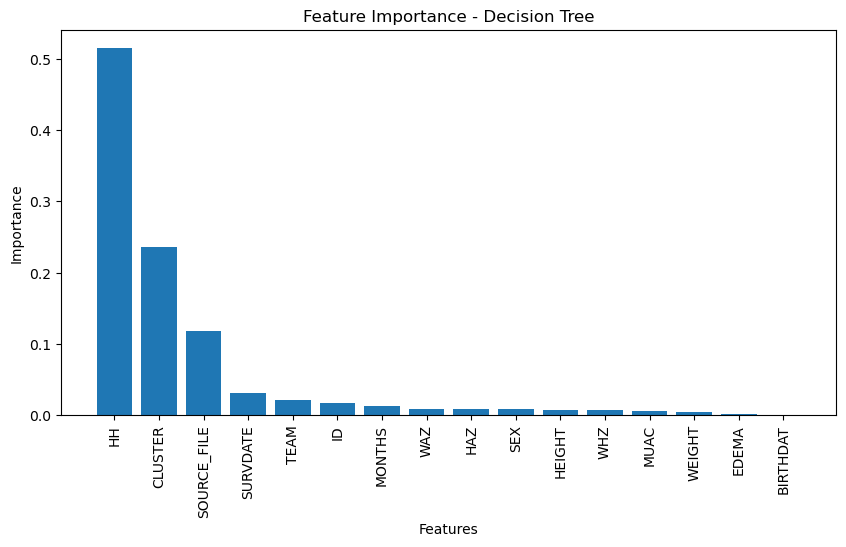

In [54]:
# ============================================================
# CELL 28 - FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("Decision Tree Feature Importance")
print("=" * 60)

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": dt_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(10,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(
    rotation=90
)

plt.title(
    "Feature Importance - Decision Tree"
)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

In [55]:
# ============================================================
# CELL 29 - SAVE BEST MODEL
# ============================================================

import joblib
from pathlib import Path

print("=" * 60)
print("Saving Best Model")
print("=" * 60)

MODEL_DIR = PROJECT_DIR / "models"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

best_model_file = MODEL_DIR / "Decision_Tree_Mortality_Model.pkl"

joblib.dump(
    dt_model,
    best_model_file
)

print("Model saved:")
print(best_model_file)

Saving Best Model
Model saved:
C:\Users\abdinasir\Desktop\group2 bit29b\models\Decision_Tree_Mortality_Model.pkl
